In [1]:
import pandas as pd
import spacy

# NLP Today — Session 1: PoS Tagging and Constituency Parsing


| Notebook section | Report section | Question it answers |
|---|---|---|
| Part 1 — Manual analysis | First part | What tags and what grammar do *we* propose, and what trees do they produce? |
| Part 2 — Automatic analysis | Second part | What do spaCy / sciSpaCy produce, how good is it, and how do their errors propagate to parsing? |
| Part 3 — Observations | Third part | What do we conclude from the comparison? |


## 0. Dataset

Six sentences: 
- four from the general domain (chosen for their syntactic ambiguity).
- two from specialty domains (biology and astronomy). 


**Manual gold-standard PoS annotation**, restricted to the tag set imposed by the assignment (`ADJ, ADP, AUX, DET, NOUN, NUM, PROPN, PUNCT, SCONJ, VERB`, plus `PRON` where unavoidable).

In [2]:
data = pd.read_csv("data/sentences.csv", sep=";")
data["n_tokens"] = data["Sentence"].str.split().str.len()
data

,Domain,Sentence,Pos,n_tokens
0,General,The cat sat on the couch,DET NOUN VERB ADP DET NOUN,6
1,General,Time flies like an arrow,NOUN VERB ADP DET NOUN,5
2,General,The spy saw the cop with the telescope,DET NOUN VERB DET NOUN ADP DET NOUN,8
3,General,The spy saw the cop with the revolver,DET NOUN VERB DET NOUN ADP DET NOUN,8
4,Specialty,Arabidopsis thaliana seedlings exhibit longer ...,PROPN PROPN NOUN VERB ADJ NOUN SCONJ PRON AUX ...,19
5,Specialty,A spectrogram of PSN J10354824 + 3900279 obtai...,DET NOUN ADP PROPN PROPN PUNCT NUM VERB ADP PR...,23


# Part 1 — Manual analysis

## 1.1 Gold-standard PoS annotation

The table below is the reference against which both automatic taggers will be scored in Part 2.
Producing it by hand is also what forced us to take explicit decisions on the hard cases
(`Arabidopsis thaliana` as `PROPN PROPN`, `+` as `PUNCT`, `which` as `PRON`, …), which we discuss
in the report.

In [3]:
GOLD = {} # dictionary mapping sentences to their gold POS tags {sentence: [POS tags]} !!!!!!!!!!! Really important to have this dictionary for the evaluation of the taggers

for _, row in data.iterrows():
    GOLD[row["Sentence"]] = row["Pos"].split()

for sentence in list(GOLD)[:4]:
    frame = {"token": sentence.split()}
    frame["gold_POS"] = GOLD[sentence]
    display(pd.DataFrame(frame).T)

,0,1,2,3,4,5
token,The,cat,sat,on,the,couch
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN


,0,1,2,3,4
token,Time,flies,like,an,arrow
gold_POS,NOUN,VERB,ADP,DET,NOUN


,0,1,2,3,4,5,6,7
token,The,spy,saw,the,cop,with,the,telescope
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN


,0,1,2,3,4,5,6,7
token,The,spy,saw,the,cop,with,the,revolver
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN


## 1.2 The grammar

The assignment restricts the non-terminals to `S`, `NP`, `VP` and `PP`, and the CYK implementation
requires **Chomsky Normal Form**: 
- `A -> B C` (two non-terminals)
- `A -> tag` (pre-terminal rule ).

We use **one single grammar for the whole general-domain subset** (not one grammar per sentence):
a grammar tailored to each individual sentence would parse everything trivially and would tell us
nothing about ambiguity, which is precisely what we want to observe.

Two design decisions are worth stating explicitly, because both fix problems of our first version:

1. **`NP -> NOUN` (bare noun) is necessary.** Without it, *Time flies like an arrow* has **no parse
   at all**: `Time` alone cannot be an `NP`, so the axiom `S -> NP VP` never applies. This was the
   silent failure of our first grammar.
2. **`VP -> VERB` (unary) must be removed.** With it, *The cat sat on the couch* returns **two
   identical analyses** (one via `VP -> VERB PP`, one via `VP -> VP PP` with `VP -> VERB`). That is
   *spurious* ambiguity — an artefact of redundant rules, not a real linguistic ambiguity — and it
   pollutes the reading of the results.

The two rules that generate **genuine** ambiguity are kept on purpose:
`VP -> VP PP` (the PP modifies the verb) and `NP -> NP PP` (the PP modifies the noun).

In [4]:

G_CORE = [
    # axiom
    ("S",  ("NP", "VP")),

    # noun phrases
    ("NP", ("DET", "NOUN")),      
    ("NP", ("NOUN", "NOUN")),     
    ("NP", ("NP", "PP")),         # AMBIGUITY: the PP modifies the noun / The spy saw the man with the telescope. The cop had the telescope
    ("NP", ("NOUN",)),            # bare noun as NP  (fixes "Time flies like an arrow")

    # verb phrases
    ("VP", ("VERB", "NP")),       
    ("VP", ("VERB", "PP")),       
    ("VP", ("VP", "PP")),         # AMBIGUITY: the PP modifies the verb / The spy saw the man with the telescope. The spy used the telescope

    # prepositional phrases
    ("PP", ("ADP", "NP")),        # on the couch, with the telescope

    # Pre-termianl rules
    ('ADJ', ('ADJ',)),
    ('ADP', ('ADP',)),
    ('AUX', ('AUX',)),
    ('DET', ('DET',)),
    ('NOUN', ('NOUN',)),
    ('NUM', ('NUM',)),
    ('PRON', ('PRON',)),
    ('PROPN', ('PROPN',)),
    ('PUNCT', ('PUNCT',)),
    ('SCONJ', ('SCONJ',)),
    ('VERB', ('VERB',))
    
]

In [5]:
def parse(grammar, tokens, pos_lists, axiom="S"):
    '''Run CYK and keep only the trees rooted in the axiom.'''
    cyk = CYK(grammar)
    trees = cyk(pos_lists, tokens)

    approved_trees = []
    for possible_tree in trees:
        if possible_tree.type == axiom:
            approved_trees.append(possible_tree)

    return approved_trees



def parse_report(grammar, sentences, gold=GOLD, show_trees=True, max_trees=2): #GOLD is a dictionary mapping sentences to their gold POS tags {sentence: [POS tags]}
    '''Parse a list of sentences and return a one-row-per-sentence summary.'''
    rows = []
    for sentence in sentences:
        tokens = sentence.split()
        pos_tags = [[t] for t in gold[sentence]]
        trees = parse(grammar, tokens, pos_tags)
        rows.append({"Sentence": sentence, "n_parses_by_CYK": len(trees)})
        if show_trees:
            print("=" * 100)
            print(sentence, f"  ->  {len(trees)} parse(s)")
            for i, tree in enumerate(trees[:max_trees], 1):
                print(f"\n--- analysis {i} ---")
                print(tree)
            if len(trees) > max_trees:
                print(f"... {len(trees) - max_trees} further analyses not shown")
    return pd.DataFrame(rows)

### Parsing the general-domain sentences

In [6]:
from src.cyk import CYK

general = data.loc[data["Domain"] == "General", "Sentence"].tolist()
core_summary = parse_report(G_CORE, general, max_trees=3)
core_summary

The cat sat on the couch   ->  1 parse(s)

--- analysis 1 ---
S
----NP
--------DET - The
--------NOUN - cat
----VP
--------VERB - sat
--------PP
------------ADP - on
------------NP
----------------DET - the
----------------NOUN - couch


Time flies like an arrow   ->  1 parse(s)

--- analysis 1 ---
S
----NP - Time
----VP
--------VERB - flies
--------PP
------------ADP - like
------------NP
----------------DET - an
----------------NOUN - arrow


The spy saw the cop with the telescope   ->  2 parse(s)

--- analysis 1 ---
S
----NP
--------DET - The
--------NOUN - spy
----VP
--------VERB - saw
--------NP
------------NP
----------------DET - the
----------------NOUN - cop
------------PP
----------------ADP - with
----------------NP
--------------------DET - the
--------------------NOUN - telescope



--- analysis 2 ---
S
----NP
--------DET - The
--------NOUN - spy
----VP
--------VP
------------VERB - saw
------------NP
----------------DET - the
----------------NOUN - cop
--------PP
--------

,Sentence,n_parses_by_CYK
0,The cat sat on the couch,1
1,Time flies like an arrow,1
2,The spy saw the cop with the telescope,2
3,The spy saw the cop with the revolver,2


## 1.3 Genuine ambiguity: PP attachment

*The spy-cop sentences* returns **exactly two analyses**, and they are the two
readings a human perceives:

* `VP -> VERB NP` with `NP -> NP PP` — the telescope/revolver belongs to **the cop**.
* `VP -> VP PP` — the telescope/revolver is the **instrument of the seeing**.

***Context-free*** grammar encodes what is *structurally possible*, not what is *plausible*.
- The spy saw the cop with the telescope. The telescope belongs to the spy
- The spy saw the cop with the revolver. The revolver belongs to the cop

In [7]:
def bracket(node):
    '''Bracketed notation, the format used by the Berkeley parser (easy side-by-side comparison).'''
    if node.left is None and node.right is None:
        return f"({node.type} {node.word})"
    children = [bracket(c) for c in (node.left, node.right) if c is not None]
    return f"({node.type} {' '.join(children)})"

In [8]:
for sentence in general[2:4]:
    print("=" * 100)
    print(sentence)
    postags_sentence = [[t] for t in GOLD[sentence]]
    for i, tree in enumerate(parse(G_CORE, sentence.split(), postags_sentence)):
        print(f"  analysis {i}: {bracket(tree)}")

The spy saw the cop with the telescope
  analysis 0: (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN telescope))))))
  analysis 1: (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN telescope)))))
The spy saw the cop with the revolver
  analysis 0: (S (NP (DET The) (NOUN spy)) (VP (VERB saw) (NP (NP (DET the) (NOUN cop)) (PP (ADP with) (NP (DET the) (NOUN revolver))))))
  analysis 1: (S (NP (DET The) (NOUN spy)) (VP (VP (VERB saw) (NP (DET the) (NOUN cop))) (PP (ADP with) (NP (DET the) (NOUN revolver)))))


## 1.4 Several candidate PoS per token

The CYK implementation accepts **a list of candidate tags per token**, which the assignment
explicitly asks us to exploit ("*considering different possible pos for each words*").

*Time flies like an arrow* is the canonical case. If we allow `flies` to be `VERB` **or** `NOUN`
and `like` to be `ADP` **or** `VERB`, the parser returns the two famous readings — the aphorism and
the entomological one (*"time flies" are a kind of insect, and they like an arrow*) — from a single
run. This is ambiguity **imported from the tagging level**, as opposed to the structural ambiguity
of section 1.3.

In [9]:
sentence = "Time flies like an arrow"
tokens = sentence.split()

print("Gold tagging (single tag per token):")
for tree in parse(G_CORE, tokens, [[t] for t in GOLD[sentence]]):
    print("  ", bracket(tree))

print("\nAmbiguous tagging (flies = VERB|NOUN, like = ADP|VERB):")
ambiguous = [["NOUN"], ["VERB", "NOUN"], ["ADP", "VERB"], ["DET"], ["NOUN"]]
for tree in parse(G_CORE, tokens, ambiguous):
    print("  ", bracket(tree))

Gold tagging (single tag per token):
   (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow)))))

Ambiguous tagging (flies = VERB|NOUN, like = ADP|VERB):
   (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow)))))
   (S (NP (NOUN Time) (NOUN flies)) (VP (VERB like) (NP (DET an) (NOUN arrow))))


## TBD 1.5 Specialty domains: the cost of coverage


In [10]:
#########################
#                       #
#         TBD           #
#                       #
#########################

G_SPEC = []

# Part 2 — Automatic analysis

## 2.1 Automatic PoS tagging: spaCy vs sciSpaCy

* **`en_core_web_sm`** — small model, trained on **general-domain** web text
* **`en_core_sci_sm`** —  small model, trained on **biomedical / scientific** text.

Initial hypothesis: the general model should win on sentences 1–4 and the scientific model on sentences 5–6. Section 2.2 tests that expectation.

In [11]:
spacy_models = {"web_sm": "en_core_web_sm", "sci_sm": "en_core_sci_sm"}

predictions = {"web_sm":{}, "sci_sm":{}} # dictionary mapping model names to their predictions {model: {sentence: [POS tags]}}
                                         # Really important to have this dictionary for the evaluation of the taggers         
for model in spacy_models:
    nlp=spacy.load(spacy_models[model])
    for sentence in data["Sentence"]:
        doc = nlp(sentence)
        predictions[model][sentence] = [token.pos_ for token in doc]

for sentence in data["Sentence"]:
    frame = {"token": sentence.split()}
    frame["gold_POS"] = GOLD[sentence]
    
    for model in spacy_models:
        frame[f"{model}_POS"] = predictions[model][sentence]

    display(pd.DataFrame(frame).T)
   


/Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshop_1/.env/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


,0,1,2,3,4,5
token,The,cat,sat,on,the,couch
gold_POS,DET,NOUN,VERB,ADP,DET,NOUN
web_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN
sci_sm_POS,DET,NOUN,VERB,ADP,DET,NOUN


,0,1,2,3,4
token,Time,flies,like,an,arrow
gold_POS,NOUN,VERB,ADP,DET,NOUN
web_sm_POS,NOUN,VERB,ADP,DET,NOUN
sci_sm_POS,NOUN,NOUN,ADP,DET,NOUN


,0,1,2,3,4,5,6,7
token,The,spy,saw,the,cop,with,the,telescope
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN


,0,1,2,3,4,5,6,7
token,The,spy,saw,the,cop,with,the,revolver
gold_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN
web_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN
sci_sm_POS,DET,NOUN,VERB,DET,NOUN,ADP,DET,NOUN


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
token,Arabidopsis,thaliana,seedlings,exhibit,longer,hypocotyls,when,they,are,grown,under,high,ambient,temperature,which,is,defined,as,thermomorphogenesis
gold_POS,PROPN,PROPN,NOUN,VERB,ADJ,NOUN,SCONJ,PRON,AUX,VERB,ADP,ADJ,ADJ,NOUN,PRON,AUX,VERB,ADP,NOUN
web_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,ADP,ADJ,ADJ,NOUN,PRON,AUX,VERB,ADP,NOUN
sci_sm_POS,NOUN,NOUN,NOUN,VERB,ADV,ADJ,SCONJ,PRON,AUX,VERB,ADP,ADJ,ADJ,NOUN,DET,AUX,VERB,ADP,NOUN


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
token,A,spectrogram,of,PSN,J10354824,+,3900279,obtained,on,Dec.,...,that,this,is,a,type,Ia,at,redshift,z,0.044
gold_POS,DET,NOUN,ADP,PROPN,PROPN,PUNCT,NUM,VERB,ADP,PROPN,...,SCONJ,PRON,AUX,DET,NOUN,PROPN,ADP,NOUN,NOUN,NUM
web_sm_POS,DET,NOUN,ADP,PROPN,PROPN,SYM,NUM,VERB,ADP,PROPN,...,SCONJ,PRON,AUX,DET,NOUN,PROPN,ADP,NOUN,NOUN,NUM
sci_sm_POS,DET,NOUN,ADP,NOUN,NOUN,CCONJ,NUM,VERB,ADP,PROPN,...,SCONJ,DET,AUX,DET,NOUN,NOUN,ADP,NOUN,NOUN,NUM


## 2.2 Quantitative evaluation against the gold standard


In [12]:
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, precision_score


def evaluate_tagger(pred_by_sentence, gold_by_sentence):

    rows =[]
    all_pred =[]
    all_gold =[]
    overall_errors = Counter()

    for sentence, pred in pred_by_sentence.items():
        gold = gold_by_sentence[sentence]
        errors = Counter(f"{gold_value} -> {pred_value}" for gold_value, pred_value in zip(gold, pred) if gold_value != pred_value)
        overall_errors.update(errors)
        all_pred.extend(pred)
        all_gold.extend(gold)

        rows.append({
            "Sentence": sentence,
            "Tokens": len(gold),
            "Accuracy": accuracy_score(gold, pred),
            "F1_macro": f1_score(gold, pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(gold, pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in errors.most_common()) or "none",
        })

    if all_gold:
        rows.append({
            "Sentence": "OVERALL",
            "Tokens": len(all_gold),
            "Accuracy": accuracy_score(all_gold, all_pred),
            "F1_macro": f1_score(all_gold, all_pred, average="macro", zero_division=0),
            "Precision_macro": precision_score(all_gold, all_pred, average="macro", zero_division=0),
            "Errors": ", ".join(f"{error} ({score})" for error, score in overall_errors.most_common()) or "none",
        })

    return pd.DataFrame(rows), overall_errors


evaluations, error_counters = {}, {}

for sentence in predictions:
    frame, errors = evaluate_tagger(predictions[sentence], GOLD)
    frame.to_csv( f"results/POS_{sentence}.csv", index=False)
    evaluations[sentence], error_counters[sentence] = frame, errors
    print(f"### {sentence} ({spacy_models[sentence]})")
    display(frame)

### web_sm (en_core_web_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch,6,1.000000,1.000000,1.000000,none
1,Time flies like an arrow,5,1.000000,1.000000,1.000000,none
2,The spy saw the cop with the telescope,8,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver,8,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,19,0.789474,0.703704,0.696296,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824 + 3900279 obtai...,23,0.956522,0.818182,0.818182,PUNCT -> SYM (1)
6,OVERALL,69,0.927536,0.724532,0.735493,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."


### sci_sm (en_core_sci_sm)


,Sentence,Tokens,Accuracy,F1_macro,Precision_macro,Errors
0,The cat sat on the couch,6,1.000000,1.000000,1.000000,none
1,Time flies like an arrow,5,0.800000,0.700000,0.666667,VERB -> NOUN (1)
2,The spy saw the cop with the telescope,8,1.000000,1.000000,1.000000,none
3,The spy saw the cop with the revolver,8,1.000000,1.000000,1.000000,none
4,Arabidopsis thaliana seedlings exhibit longer ...,19,0.736842,0.600000,0.626667,"PROPN -> NOUN (2), ADJ -> ADV (1), NOUN -> ADJ..."
5,A spectrogram of PSN J10354824 + 3900279 obtai...,23,0.782609,0.645336,0.658009,"PROPN -> NOUN (3), PUNCT -> CCONJ (1), PRON ->..."
6,OVERALL,69,0.840580,0.638325,0.711689,"PROPN -> NOUN (5), PRON -> DET (2), VERB -> NO..."


In [13]:
# Accuracy per sentence, both models side by side -> the general vs specialty contrast in one table.

reference = next(iter(evaluations))
accuracy = pd.DataFrame({name: frame["Accuracy"].tolist() for name, frame in evaluations.items()},
                        index=evaluations[reference]["Sentence"])
accuracy.insert(0, "Domain", list(data["Domain"]) + ["-"])

accuracy.to_csv("results/POS_accuracy_comparison.csv")
accuracy.round(3)

,Domain,web_sm,sci_sm
Sentence,,,
The cat sat on the couch,General,1.000,1.000
Time flies like an arrow,General,1.000,0.800
The spy saw the cop with the telescope,General,1.000,1.000
The spy saw the cop with the revolver,General,1.000,1.000
Arabidopsis thaliana seedlings exhibit longer hypocotyls when they are grown under high ambient temperature which is defined as thermomorphogenesis,Specialty,0.789,0.737
A spectrogram of PSN J10354824 + 3900279 obtained on Dec. 19.33 UT suggests that this is a type Ia at redshift z 0.044,Specialty,0.957,0.783
OVERALL,-,0.928,0.841


In [14]:
# Which confusions does each model make?
errors_frame = pd.DataFrame(
    {name: pd.Series(counter) for name, counter in error_counters.items()}
).fillna(0).astype(int).sort_values(list(error_counters), ascending=False)

errors_frame

,web_sm,sci_sm
PROPN -> NOUN,2,5
ADJ -> ADV,1,1
NOUN -> ADJ,1,1
PUNCT -> SYM,1,0
PRON -> DET,0,2
PUNCT -> CCONJ,0,1
VERB -> NOUN,0,1


## 2.3 How tagging errors propagate to parsing 
Needs to be finished

This is the section that connects Part 1 and Part 2, and the one the assignment asks for when it
says to *"discuss the different results depending on the pos tag"*. We re-run **the same grammars**
(`G_CORE` for the general sentences, `G_SPEC` for the specialty ones), changing only the tag
sequence: gold, `web_sm`, `sci_sm`.

In [15]:
G_SPEC = []  # To be implemented


def grammar_for(sentence):
    return G_CORE if sentence in set(general) else G_SPEC


rows = []
general_set = set(general)

for sentence in data["Sentence"]:

    tokens = sentence.split()

    if sentence in set(general):
        grammar = G_CORE
    else:
        grammar = G_SPEC


    row = {
        "Sentence": sentence,
        "grammar": "G_CORE" if sentence in general_set else "G_SPEC"
    }

    if not grammar:
        row["n_parses_gold"] = None

        for modelo in predictions:
            row[f"n_parses_{modelo}"] = None

        rows.append(row)
        continue

    taggings = {"gold": GOLD[sentence]}

    taggings.update({
        modelo: tags[sentence]
        for modelo, tags in predictions.items()
    })

    for modelo, tags in taggings.items():

        if len(tags) == len(tokens):

            trees = parse(
                grammar,
                tokens,
                [[t] for t in tags]
            )

            row[f"n_parses_{modelo}"] = len(trees)

        else:
            row[f"n_parses_{modelo}"] = None

    rows.append(row)


parses_by_tagging = pd.DataFrame(rows)

parses_by_tagging.to_csv(
    "results/parses_by_tagging.csv",
    index=False
)

parses_by_tagging

,Sentence,grammar,n_parses_gold,n_parses_web_sm,n_parses_sci_sm
0,The cat sat on the couch,G_CORE,1.0,1.0,1.0
1,Time flies like an arrow,G_CORE,1.0,1.0,0.0
2,The spy saw the cop with the telescope,G_CORE,2.0,2.0,2.0
3,The spy saw the cop with the revolver,G_CORE,2.0,2.0,2.0
4,Arabidopsis thaliana seedlings exhibit longer ...,G_SPEC,NaN,NaN,NaN
5,A spectrogram of PSN J10354824 + 3900279 obtai...,G_SPEC,NaN,NaN,NaN


In [16]:
# The clearest case: sciSpaCy tags "flies" as NOUN, and the sentence loses its verb.
sentence = "Time flies like an arrow"
print(f"Sentence: {sentence}")
for name in ["gold"] + list(predictions):
    tags = GOLD[sentence] if name == "gold" else predictions[name][sentence]
    trees = parse(G_CORE, sentence.split(), [[t] for t in tags])
    print(f"{name:7s} {tags}  ->  {len(trees)} parse(s)")
    for tree in trees:
        print("        ", bracket(tree))

Sentence: Time flies like an arrow
gold    ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN']  ->  1 parse(s)
         (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow)))))
web_sm  ['NOUN', 'VERB', 'ADP', 'DET', 'NOUN']  ->  1 parse(s)
         (S (NP Time) (VP (VERB flies) (PP (ADP like) (NP (DET an) (NOUN arrow)))))
sci_sm  ['NOUN', 'NOUN', 'ADP', 'DET', 'NOUN']  ->  0 parse(s)


## 2.4 Reference constituency parses

To have an external point of comparison we parsed the same sentences with the
**Berkeley Neural Parser** (online demo): it does not expose the ambiguity, it resolves it with the
preferences learned from its training. The images below are the parses it produced.

The question to ask each figure is the one from section 1.3: **where does the PP attach**, and does
the answer change between *telescope* and *revolver*?

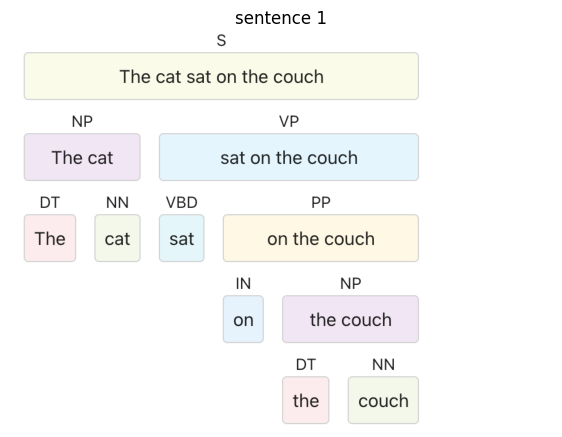

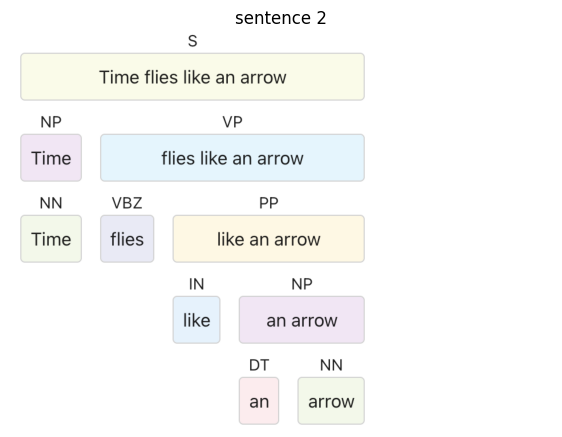

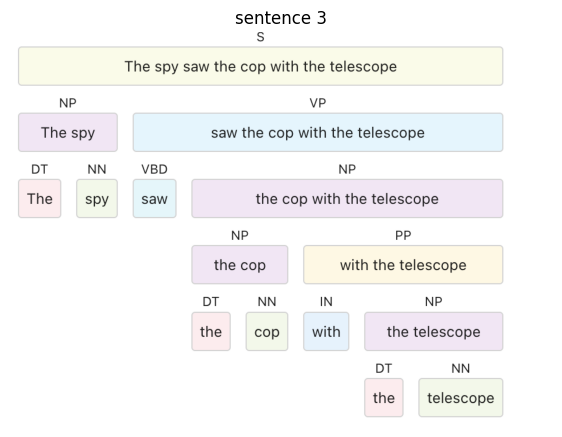

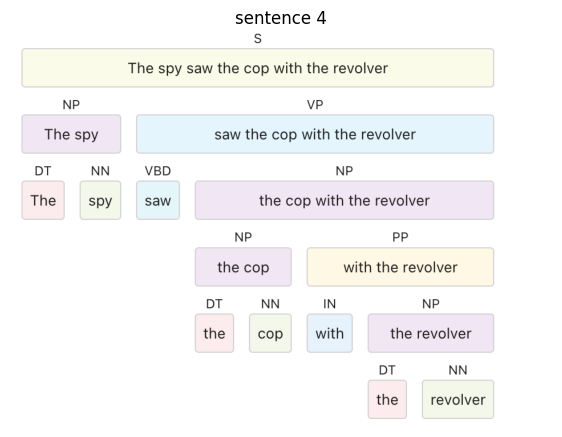

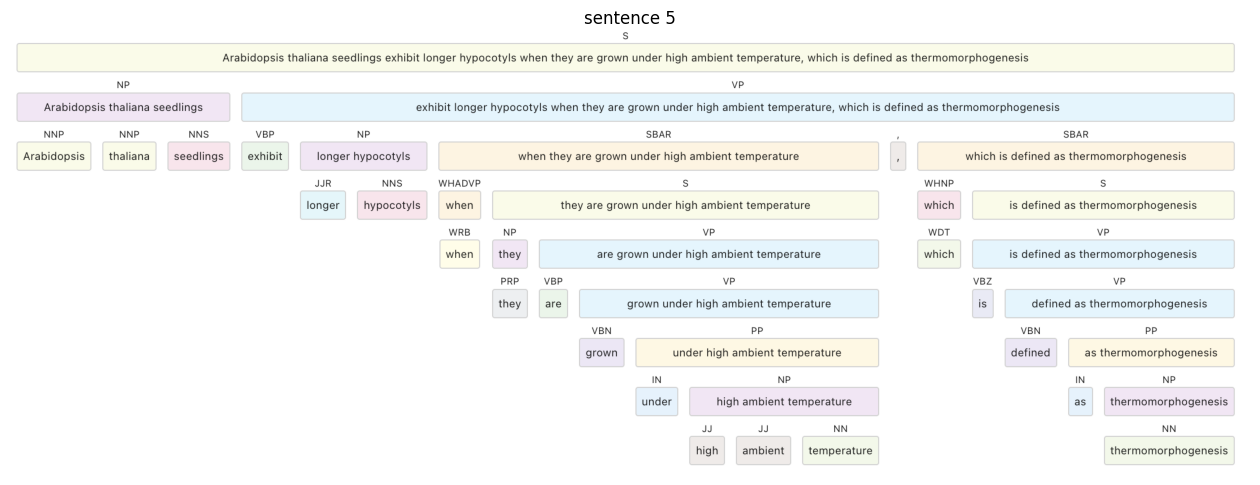

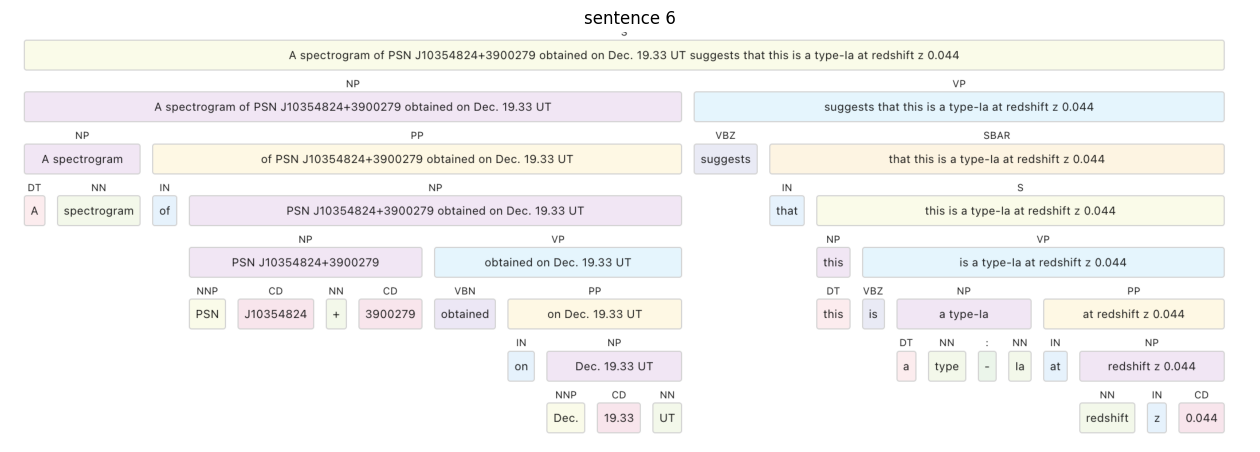

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

folder = Path("Berkeley_Neural_Parser")

for path in sorted(folder.iterdir()):

    if path.stem in {"sentence_5", "sentence_6"}:
        size = (16, 16)
    else:
        size = (7, 7)
        
    plt.figure(figsize=size)
    plt.imshow(Image.open(path))
    plt.title(path.stem.replace("_", " "))
    plt.axis("off")
    plt.show()

# Part 3 — Observations TBD
